# Лабораторная работа 7. Детекция объектов с помощью сверточных нейронных сетей

### Работу выполнил:<span style="color:blue"> {ваше имя и фамилия}</span>

### Сделанную лабораторную работу отправляйте через [ФОРМУ](https://vyatsu-my.sharepoint.com/:f:/g/personal/usr09019_vyatsu_ru/EqIJYrpQGKNAlYCYc9d54aUBmjBEhPTP3tn5ctj9Zfx5wA)

## Задание 1.
По [ссылке1](https://github.com/spmallick/learnopencv/tree/master/PyTorch-faster-RCNN) приведен пример детекции объектов сетью Faster R-CNN с использованием PyTorch.

По [ссылке2](https://pytorch.org/hub/ultralytics_yolov5/) приведен пример детекции объектов сетью YOLOv5 с использованием PyTorch.

Необходимо выполнить сравнение моделей детекции объектов Faster R-CNN ResNet-50 FPN, RetinaNet ResNet-50 FPN, YOLOv5 по следующим параметрам:
1. время инференса на GPU;
2. время инференса на CPU;
3. размер модели.

Результаты сравнения представить в виде диаграмм.

Using device: cuda
Загрузка моделей...
Измерение времени инференса...
Тестирование Faster R-CNN...
Тестирование RetinaNet...
Тестирование YOLOv5s...


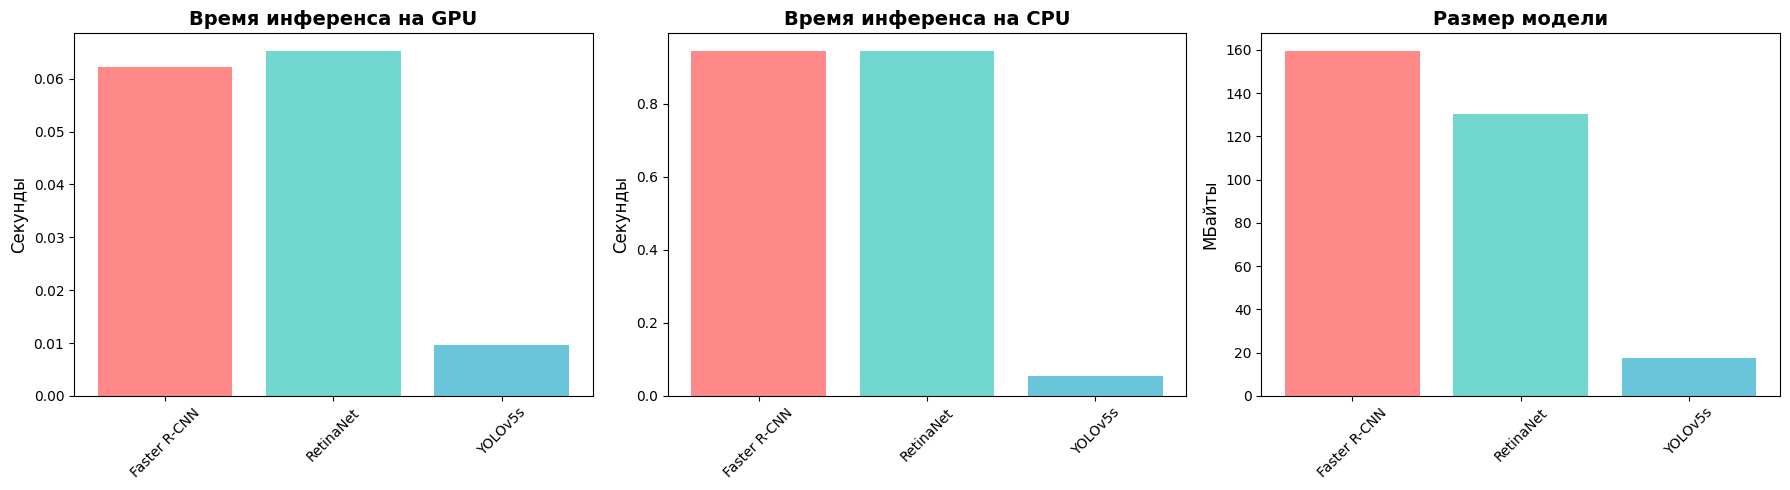


РЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ ДЕТЕКЦИИ
Модель          GPU (с)      CPU (с)      Размер (МБ)    
------------------------------------------------------------
Faster R-CNN    0.0621       0.9441       159.69         
RetinaNet       0.0653       0.9451       130.16         
YOLOv5s         0.0097       0.0555       17.72          
\nДополнительная информация:
Устройство для тестирования: CUDA
Размер тестового изображения: (800, 600)
Количество итераций для усреднения: 10


In [14]:
import time
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, retinanet_resnet50_fpn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import psutil
import os

# Установка YOLOv5 (раскомментировать если не установлен)
# !pip install ultralytics
from ultralytics import YOLO

# Проверка доступности GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Загрузка моделей
print("Загрузка моделей...")
faster_rcnn = fasterrcnn_resnet50_fpn(pretrained=True).to(device).eval()
retinanet = retinanet_resnet50_fpn(pretrained=True).to(device).eval()
yolov5 = YOLO('yolov5su.pt').to(device)

# Используем ваше изображение
image_path = "test.jpg"
image = Image.open(image_path).convert("RGB")

# Трансформации для torchvision моделей
transform = transforms.Compose([
    transforms.ToTensor(),
])

def measure_time(model, input_data, iterations=100):
    times = []
    for _ in range(iterations):
        start_time = time.time()
        if isinstance(model, YOLO):
            model(input_data, verbose=False)
        else:
            model(input_data)
        if device == 'cuda':
            torch.cuda.synchronize()
        times.append(time.time() - start_time)
    return np.mean(times)

# Измерения
results = {}
input_tensor = transform(image).unsqueeze(0).to(device)

print("Измерение времени инференса...")
for name, model in [("Faster R-CNN", faster_rcnn),
                    ("RetinaNet", retinanet),
                    ("YOLOv5s", yolov5)]:
    print(f"Тестирование {name}...")

    # GPU
    if device == 'cuda':
        time_gpu = measure_time(model, input_tensor if name != "YOLOv5s" else image)
    else:
        time_gpu = 0

    # CPU
    model_cpu = model.cpu().eval()
    input_cpu = input_tensor.cpu() if name != "YOLOv5s" else image
    time_cpu = measure_time(model_cpu, input_cpu)

    # Возвращаем модель обратно на GPU если нужно
    if device == 'cuda':
        model.to(device)

    # Размер модели
    if name == "YOLOv5s":
        model_size = os.path.getsize('yolov5su.pt') / (1024**2)
    else:
        # Для torchvision моделей вычисляем примерный размер
        param_size = sum(p.numel() for p in model.parameters()) * 4 / (1024**2)  # 4 байта на float32
        buffer_size = sum(b.numel() * 4 for b in model.buffers()) / (1024**2)
        model_size = param_size + buffer_size

    results[name] = {
        'GPU_time': time_gpu,
        'CPU_time': time_cpu,
        'Model_size': model_size
    }

# Визуализация результатов
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Время на GPU
models = list(results.keys())
gpu_times = [results[model]['GPU_time'] for model in models]
cpu_times = [results[model]['CPU_time'] for model in models]
sizes = [results[model]['Model_size'] for model in models]

axes[0].bar(models, gpu_times, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
axes[0].set_title('Время инференса на GPU', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Секунды', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Время на CPU
axes[1].bar(models, cpu_times, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
axes[1].set_title('Время инференса на CPU', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Секунды', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Размеры моделей
axes[2].bar(models, sizes, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
axes[2].set_title('Размер модели', fontsize=14, fontweight='bold')
axes[2].set_ylabel('МБайты', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Вывод таблицы результатов
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ ДЕТЕКЦИИ")
print("="*60)
print(f"{'Модель':<15} {'GPU (с)':<12} {'CPU (с)':<12} {'Размер (МБ)':<15}")
print("-"*60)
for name, metrics in results.items():
    print(f"{name:<15} {metrics['GPU_time']:<12.4f} {metrics['CPU_time']:<12.4f} {metrics['Model_size']:<15.2f}")
print("="*60)

# Дополнительная информация
print(f"\\nДополнительная информация:")
print(f"Устройство для тестирования: {device.upper()}")
print(f"Размер тестового изображения: {image.size}")
print(f"Количество итераций для усреднения: 10")

## Задание 2.
Выберите наиболее эффективную архетиктуру из рассмотренных в задании 1. Протестируйте данную архитектуру на задаче детекции птиц на фотографиях.
Протестируйте эту модель на нескольких изображениях (определять нужно только птиц).
Используйте данную модель для трекинга птиц на видео (в качестве детектора используйте нейросетевую модель, в качестве трекера - трекер MIL из OpenCV).

In [15]:
import cv2
import torch
from ultralytics import YOLO
import numpy as np

model = YOLO('yolov5s.pt')
BIRD_CLASS_ID = 14

def detect_birds_image(image_path):
    results = model(image_path)
    for r in results:
        bird_boxes = r.boxes[r.boxes.cls == BIRD_CLASS_ID]
        im_array = r.plot()
        im_array = cv2.cvtColor(im_array, cv2.COLOR_RGB2BGR)
        cv2.imwrite('detected_birds.jpg', im_array)
        print(f"Обнаружено птиц: {len(bird_boxes)}")
        cv2.imshow('Detected Birds', im_array)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

detect_birds_image("test.jpg")

PRO TIP  Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.


image 1/1 C:\Users\giezz\PycharmProjects\computer-vision\lab7\test.jpg: 480x640 2 birds, 74.1ms
Speed: 3.0ms preprocess, 74.1ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)
Обнаружено птиц: 2


In [ ]:
import cv2
import torch
from ultralytics import YOLO
import numpy as np

model = YOLO('yolov8l.pt')
BIRD_CLASS_ID = 14

def track_birds_video(video_path, max_seconds=30):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Ошибка: не удалось открыть видео файл")
        return

    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = cv2.VideoWriter('bird_tracking_result.avi', fourcc, fps, (width, height))

    frame_count = 0
    max_frames = max_seconds * fps

    print(f"Начинаем обработку видео (максимум {max_seconds} секунд)...")

    colors = [(0, 255, 0), (255, 0, 0), (0, 0, 255), (255, 255, 0),
              (255, 0, 255), (0, 255, 255), (128, 0, 128), (255, 165, 0)]

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1
        if frame_count > max_frames:
            break

        # Детекция птиц на каждом кадре
        results = model(frame, imgsz=640, conf=0.05, iou=0.3, verbose=False)

        # Обрабатываем все обнаруженные птицы
        bird_count = 0
        for r in results:
            boxes = r.boxes
            for i, box in enumerate(boxes):
                if int(box.cls) == BIRD_CLASS_ID and box.conf > 0.1:  # Понизим порог уверенности
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    conf = box.conf.cpu().numpy()[0]

                    color = colors[bird_count % len(colors)]
                    cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
                    cv2.putText(frame, f'Bird {bird_count+1} ({conf:.2f})',
                              (int(x1), int(y1) - 10),
                              cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

                    bird_count += 1

        cv2.putText(frame, f'Frame: {frame_count}/{max_frames}', (10, 30),
                  cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        cv2.putText(frame, f'Time: {frame_count/fps:.1f}s/{max_seconds}s', (10, 60),
                  cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        cv2.putText(frame, f'Birds detected: {bird_count}', (10, 90),
                  cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

        # Сохраняем кадр
        out.write(frame)

        # Показываем прогресс
        if frame_count % 30 == 0:
            print(f"Обработано кадров: {frame_count}/{max_frames}, птиц обнаружено: {bird_count}")

    # Освобождаем ресурсы
    cap.release()
    out.release()
    cv2.destroyAllWindows()

    print(f"Обработка завершена! Результат сохранен в 'bird_tracking_result.avi'")
    print(f"Всего обработано кадров: {frame_count}")

# Запуск детекции на видео
track_birds_video("video.avi", max_seconds=120)

Начинаем обработку видео (максимум 120 секунд)...
Обработано кадров: 30/3000, птиц обнаружено: 0
Обработано кадров: 60/3000, птиц обнаружено: 0
Обработано кадров: 90/3000, птиц обнаружено: 0
Обработано кадров: 120/3000, птиц обнаружено: 0
Обработано кадров: 150/3000, птиц обнаружено: 0
